# Part 3 Lyrics Generation.

### Load Libraries

In [ ]:
import gdown
import os,glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer


### Load Test data and saved Models from the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# url = "https://drive.google.com/drive/folders/1wl82IEN7A2ujuYAIJHvsoOYvB7l_tHJK?usp=sharing"
# gdown.download_folder (url, quiet=True, use_cookies=False)

### Test Data Preprocessing

In [ ]:
import pandas as pd

# Load the lyrics dataset
lyrics_data = pd.read_csv("/content/drive/MyDrive/original_dataset/train.csv")  # Replace with the actual dataset path


In [ ]:
# Grouping data by Artist and calculate song count
artist_song_count = lyrics_data.groupby("Artist")["Song"].count().reset_index()


In [ ]:
#Sorting artists by song count in descending order
sorted_artists = artist_song_count.sort_values(by="Song", ascending=False)

In [ ]:
#
top_3_artists = sorted_artists.head(3)

In [ ]:
top_3_artists

,Artist,Song
4883,elvis presley,1611
2969,chris brown,1239
4878,elvis costello,923


In [ ]:
#Creating a new dataset for top 10 artists
top_3_artist_data = lyrics_data[lyrics_data["Artist"].isin(top_3_artists["Artist"])]

In [ ]:
# Displaying the new dataset for top 10 artists
print(top_3_artist_data)

                Artist                                               Song  \
16793   elvis costello                                                she   
16794   elvis costello                                      sparkling day   
16795   elvis costello                                             alison   
16796   elvis costello  (what's so funny 'bout) peace love and underst...   
16797   elvis costello                                          beautiful   
...                ...                                                ...   
289223     chris brown                                            twitter   
289476     chris brown                                              smash   
289664   elvis presley                                     echoes of love   
289790   elvis presley                          he knows just what i need   
289948     chris brown                                       i get around   

          Genre Language                                             Lyrics

In [ ]:
# Saving the combined dataset to a CSV file after cleaning the dataset
top_3_artist_data.to_csv("/content/drive/MyDrive/Data_Saved/top_3_artist_dataset.csv", index=False)

In [ ]:
top_3_artist_data

,Artist,Song,Genre,Language,Lyrics
16793,elvis costello,she,Rock,en,She\nMay be the face I can't forget.\nA trace ...
16794,elvis costello,sparkling day,Rock,en,"Oh, it was such a sparkling day\nThat I should..."
16795,elvis costello,alison,Rock,en,"Oh, it's so funny to be seeing you after so lo..."
16796,elvis costello,(what's so funny 'bout) peace love and underst...,Rock,en,As I walk through\nThis wicked world\nSearchin...
16797,elvis costello,beautiful,Rock,en,"Every day is so wonderful\nAnd suddenly, it's ..."
...,...,...,...,...,...
289223,chris brown,twitter,Hip-Hop,en,"(Uh) Look, I does my S-H-I-T Please excuse me ..."
289476,chris brown,smash,Hip-Hop,en,"Guess who's steppin' in the room, It's your bo..."
289664,elvis presley,echoes of love,Rock,en,"Though you are gone, I still wear your ring Th..."
289790,elvis presley,he knows just what i need,Rock,en,My Jesus knows when I am Lonely He knows each ...


In [ ]:
top_3_artist_data.isnull().sum()

Artist      0
Song        0
Genre       0
Language    0
Lyrics      0
dtype: int64

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt


In [ ]:
# Spliting data into train, validation, and no testset in this section
#dividing data into 90% and 10% testset

train_data, val_data = train_test_split(top_3_artist_data, test_size=0.1, random_state=42, stratify =top_3_artist_data["Artist"])


In [ ]:
# Converting artist labels to one-hot encoding as it is a multiclass classification

#Converting first artist labels to integers using label encoding
label_encoder = LabelEncoder()
train_data["Artist"] = label_encoder.fit_transform(train_data["Artist"])
val_data["Artist"] = label_encoder.transform(val_data["Artist"])


In [ ]:
#Total number of classes
num_classes = len(label_encoder.classes_)

In [ ]:
# Creating TF-IDF text vectorizer

#When we run population data we can keep 10000 or more
#For now we are keeping 5000 for model building and computational purpose

max_features = 5000  # we can adjust as needed

tfidf_vectorizer = TfidfVectorizer(max_features=max_features)

In [ ]:
# Fitting and transforming the text data
#training set
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data["Lyrics"])
#validation set
X_val_tfidf = tfidf_vectorizer.transform(val_data["Lyrics"])



In [ ]:
# Converting secondly Artist labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(train_data["Artist"], num_classes)
y_val = tf.keras.utils.to_categorical(val_data["Artist"], num_classes)


In [ ]:
# Converting sparse matrices to dense arrays
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense = X_val_tfidf.toarray()


In [ ]:
#Data saving for further use in future

np.savez('/content/drive/MyDrive/original_dataset/Task_2_model_weights/top_3_artist_train_test.npz',
         X_train=X_train_tfidf_dense,y_train=y_train, X_val = X_val_tfidf_dense, y_val= y_val)

MultiLayer Model LSTM

In [ ]:
import gdown
import os,glob
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import ast
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Concatenate, Dense, LSTM, Input,GRU, concatenate,Dropout,LeakyReLU,SimpleRNN,Reshape
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Input,Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import one_hot
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import Flatten
from keras.models import Model
import joblib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from tensorflow.keras.layers import SimpleRNN, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential

In [ ]:
# Building and compile the models
def build_multi_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=False))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())
    return model_lstm

In [ ]:
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion
multi_layer_lstm_gen_model = build_multi_layer_lstm_model()
multi_layer_lstm_gen_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5000, 128)         640000    
                                                                 
 lstm (LSTM)                 (None, 5000, 128)         131584    
                                                                 
 dropout (Dropout)           (None, 5000, 128)         0         
                                                                 
 lstm_1 (LSTM)               (None, 5000, 128)         131584    
                                                                 
 dropout_1 (Dropout)         (None, 5000, 128)         0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10

print("Printing multilayer layer lstm epochs")

multi_layer_lstm_gen_history = multi_layer_lstm_gen_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing multilayer layer lstm epochs
Epoch 1/10
107/107 [==============================] - 57s 418ms/step - loss: 1.1319 - accuracy: 0.3844 - val_loss: 1.0936 - val_accuracy: 0.4259
Epoch 2/10
107/107 [==============================] - 44s 410ms/step - loss: 1.1180 - accuracy: 0.3841 - val_loss: 1.0924 - val_accuracy: 0.4259
Epoch 3/10
107/107 [==============================] - 44s 415ms/step - loss: 1.1110 - accuracy: 0.3900 - val_loss: 1.0869 - val_accuracy: 0.4259
Epoch 4/10
107/107 [==============================] - 44s 413ms/step - loss: 1.0961 - accuracy: 0.4018 - val_loss: 1.0880 - val_accuracy: 0.4259
Epoch 5/10
107/107 [==============================] - 44s 414ms/step - loss: 1.0926 - accuracy: 0.4003 - val_loss: 1.0920 - val_accuracy: 0.4259


Ploting

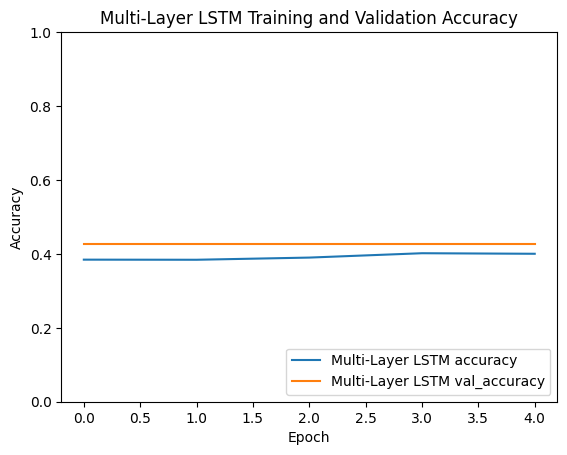

In [ ]:
# Plot training and validation accuracy as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(multi_layer_lstm_gen_history, 'Multi-Layer LSTM')

In [ ]:
max_len=5000

In [ ]:
# Generate lyrics using the trained model
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer()
for artist in ["elvis presley", "chris brown","elvis costello"]:
    seed_text = "The song lyrics is related to the artist of " + artist
    for i in range(10):
        encoded_text = tokenizer.texts_to_sequences([seed_text])[0]
        padded_text = pad_sequences([encoded_text], maxlen=max_len, padding="post")
        prediction = multi_layer_lstm_gen_model.predict(padded_text)[0]
        predicted_word_index = np.argmax(prediction)
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                predicted_word = word
                break
        seed_text += " " + predicted_word
    print("Generated " + artist + " song : " + seed_text)

1/1 [==============================] - 0s 160ms/step
Generated elvis presley song : The song lyrics is related to the artist of elvis presley          
1/1 [==============================] - 0s 159ms/step
Generated chris brown song : The song lyrics is related to the artist of chris brown          
1/1 [==============================] - 0s 160ms/step
Generated elvis costello song : The song lyrics is related to the artist of elvis costello          
